### Import Library ###

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

### Inisialisasi ###

In [3]:
N1, a1 = 21, 2
shots = 20000                           #Jumlah pengukuran (runs) per simulasi
n_count1 = math.ceil(math.log2(N1**2))  #8 kubit
Q1 = 2**n_count1                        #256

In [4]:
N2, a2 = 111, 5
n_count2 = math.ceil(math.log2(N2**2)) // 2 #7 kubit
Q2 = 2**n_count2                            #128

In [5]:
def c_amod15(a, power):
    # Normalisasi a agar nilainya dalam range 0-14
    a = a % 15
    # Validasi: a harus relatif prima dengan 15
    # syarat Shor's algorithm: gcd(a,N)=1
    # jika tidak, faktor sudah ditemukan secara klasik
    if math.gcd(a, 15) != 1:
        raise ValueError(f"gcd({a},15) != 1")

    U = QuantumCircuit(4)           # Buat quantum circuit dengan 4 qubit (work register)
    # Ulangi operasi sebanyak 'power' kali
    # misal power=4 → U diterapkan 4 kali = U^4
    for _ in range(power):
        if a == 2:                  # 2*y mod 15: geser bit ke kiri (rotasi siklik)                 
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        elif a == 4:                # 4*y mod 15: geser 2 bit ke kiri
            U.swap(0, 2); U.swap(1, 3)
        elif a == 7:                # 7*y mod 15: kebalikan dari a=2
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        elif a == 8:                # 8*y mod 15: kombinasi rotasi
            U.swap(2, 3); U.swap(0, 2); U.swap(1, 3)
        elif a == 11:               # 11*y mod 15: 11 = -4 mod 15, kebalikan dari a=4
            U.swap(1, 3); U.swap(0, 2)
        elif a == 13:               # 13*y mod 15: 13 = -2 mod 15, kebalikan dari a=2
            U.swap(0, 3); U.swap(1, 2)
        else:
            raise ValueError(f"a={a} belum didukung untuk N=15")    # a selain di atas tidak didukung untuk N=15

    c_U = U.to_gate().control(1)    # Konversi circuit U menjadi gate
                                    # lalu tambahkan 1 control qubit → controlled-U gate
    c_U.label = f"a^{power} mod 15" # Beri label untuk memudahkan visualisasi circuit
    return c_U

In [6]:
def c_amod_N(a, power, N, n_work):
    # Hitung dimensi Hilbert space = 2^n_work
    dim = 2**n_work

    # Hitung a^power mod N secara klasik
    # pow(a, power, N) = fast modular exponentiation
    a_pow = pow(int(a), int(power), int(N))
    # Matriks permutasi
    # matriks ini merepresentasikan U|y⟩ = |a^power * y mod N⟩
    U = np.zeros((dim,dim))
    for y in range(dim):
        # Jika y < N: terapkan perkalian modular
        # Jika y >= N: biarkan state tidak berubah (identitas)    
        new_y = (a_pow*y) % N if y < N else y 
        U[new_y,y] = 1.0        # artinya: state |y⟩ dipetakan ke state |new_y⟩

# Buat quantum circuit dengan n_work qubit
    gate = QuantumCircuit(n_work, name=f'U^{power} mod {N}')
    # Masukkan matriks U sebagai unitary gate
    gate.unitary(U, list(range(n_work)))
    # controlled-U: jika control=|1⟩ → terapkan U
    #               jika control=|0⟩ → tidak terjadi apa-apa
    return gate.to_gate().control(1)

In [7]:
# Exact QFT
# Inverse QFT (QFT†) - digunakan di akhir QPE
# QFT† = kebalikan dari QFT, untuk mengekstrak informasi fase
def qft_dagger(circuit, n):
    # Stage 1: Balik urutan qubit (bit-reversal)
    # karena output QFT urutan bit-nya terbalik
    for qubit in range(n//2):
        circuit.swap(qubit, n-qubit-1)
        # n=8: swap(0,7), swap(1,6), swap(2,5), swap(3,4)

    # Stage 2: Controlled-phase negatif + Hadamard
    # negatif karena ini INVERSE QFT (kebalikan QFT biasa)
    for j in range(n):
        for m in range(j):
            # sudut makin kecil saat j-m makin besar
            circuit.cp(-np.pi/(2**(j-m)), m, j)
        # Hadamard setelah semua rotasi fase selesai
        circuit.h(j)

In [8]:
# Approximate QFT
# Memangkas gate dengan sudut rotasi sangat kecil (< π/2^kmax)
# Mengurangi jumlah gate dari O(L²) → O(L log L)
def approx_qft_dagger(circuit, n, kmax):    # kmax = threshold maksimum jarak qubit yang masih dirotasi

    # Stage 1: Balik urutan qubit (sama seperti exact QFT†)
    for qubit in range(n//2):
        circuit.swap(qubit, n-qubit-1)

    # Stage 2: Controlled-phase negatif + Hadamard
    # dengan threshold kmax
    for j in range(n):
        for m in range(j):
            if (j-m) <= kmax:               # Gate DIPAKAI jika jarak j-m masih dalam threshold
                circuit.cp(-np.pi/(2**(j-m)), m, j)
                # Gate DIPANGKAS jika (j-m) > kmax

        circuit.h(j)

In [9]:
#Build full Shor's circuit (QPE + Modular exp)
def build_circuit(N, a, n_count, use_approx=False):

    n_work = 4 if N==15 else math.ceil(math.log2(N+1))
    qc = QuantumCircuit(n_count + n_work, n_count)

    #Hadamard pada counting register
    for q in range(n_count): 
        qc.h(q)     #n_count qubit dikenai Hadamard, untuk estimasi fase

    #inisialisasi work register ke |1> 
    qc.x(n_count) #n_work qubit (lower/work register), tempat modular exponentiaton

    #Controlled-U^(2^k)
    for k in range(n_count):
        power = 2**k
        if N == 15:
            cu = c_amod15(a, power)
        else:
            cu = c_amod_N(a, power, N, n_work)
        #control = kubit k, target = work register
        qc.append(cu, [k] + list(range(n_count, n_count + n_work)))

    #Inverse QFT pada counting register
    if use_approx:
        kmax = max (1, int(np.log2(n_count)))
        approx_qft_dagger(qc, n_count, kmax)
    else:
        qft_dagger(qc, n_count)

    #Ukur counting register
    for i in range(n_count):
        qc.measure(i,i)

    return qc

In [10]:
#Simulasi (probability array)
def simulate(qc, Q):
    sim = AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots).result()
    counts = result.get_counts()

    prob = np.zeros(Q)
    for state,count in counts.items():
        prob[int(state,2)] = count/shots

    return prob

In [11]:
#Menghitung periode r
def get_period_classical(a,N):
    r = 1   #mulai hitung dari eksponen 1
    val = a % N #val = a^1 mod N

    while val != 1 and r < N * 10:  #terus kalikan sampai val = 1
        val = (val*a) % N   #val = a^(r+1) mod N
        r = r+1
    return r    #r = period yg ditemukan

In [12]:
#Distribusi teoritis
def theory_distribution(r, Q):
    prob = np.zeros(Q)
    for x in range(Q):
        total = 0
        for s in range(r):
            peak = s * Q / r
            diff = x - peak
            if abs(diff) < 1e-10:
                total += 1.0 / r
            else:
                num = np.sin(np.pi * diff)
                den = Q * np.sin(np.pi * diff / Q)
                if abs(den) > 1e-10:
                    total += (1/r) * (num/den) ** 2
        prob[x] = total

    # Normalisasi
    if prob.sum() > 0:
        prob = prob / prob.sum()

    # Buang nilai yang terlalu kecil (noise)
    threshold = 0.5 / r   # setengah dari nilai peak
    prob[prob < threshold] = 0
    
    # Normalisasi ulang setelah threshold
    if prob.sum() > 0:
        prob = prob / prob.sum()
    
    return prob

In [13]:
#Menghitung brp persen shots yg berhasil menemukan faktor N.
def correctness(counts, n_count, N, a, shots, label=''):
    r = get_period_classical(a,N)
    Q = 2**n_count  #jumlah total states(256 utk N=15)
    good = 0        #counter shots yg berhasil
    for state, count in counts.items():
        x = int(state, 2)   #konversi bitstring '01000000' angka 64
        if x == 0:
            continue        #skip state 0 
        phase = x / Q       #misal x=64, Q=256 → phase = 64/256 = 0.25
                            #ini estimasi dari s/r (s adalah integer 0..r-1)
        frac = Fraction(phase).limit_denominator(N)
        r_candidate = frac.denominator  #Continued fraction algorithm:
                                        # 0.25 → Fraction(1/4) → denominator = 4
        if r_candidate % 2 == 0:       #r harus genap
            guess1 = math.gcd(pow(int(a), r_candidate // 2, int(N)) + 1, N)
            guess2 = math.gcd(pow(int(a), r_candidate // 2, int(N)) - 1, N)
            if 1 < guess1 < N or 1 < guess2 < N:
                good += count
                print(f'[{label}] state={x}, phase={phase:.4f}, r={r_candidate}, faktor={guess1} dan {guess2}')
    return good / shots * 100       #persentase
        

In [14]:
#Jalankan simulasi
#N = 15
shots_15 = 20000
print('N=15 Exact QFT...')
qc_exact1 = build_circuit(N1, a1, n_count1, use_approx=False)
print('N=15 Approx QFT...')
qc_approx1 = build_circuit(N1, a1, n_count1 ,use_approx=True)

sim = AerSimulator()
res_exact1 = sim.run(transpile(qc_exact1, sim), shots=shots_15).result()
res_approx1 = sim.run(transpile(qc_approx1, sim), shots=shots_15).result()

prob_exact1 = simulate(qc_exact1, Q1)
prob_approx1 = simulate(qc_approx1, Q1)
prob_theory1 = theory_distribution(get_period_classical(a1, N1), Q1)

CE1 = correctness(res_exact1.get_counts(), n_count1, N1, a1, shots_15, label='N=15 Exact')
CA1 = correctness(res_approx1.get_counts(), n_count1, N1, a1, shots_15, label='N=15 Approx')

#N = 111
shots_111 = 1024
print('N=111 Exact QFT...')
qc_exact2 = build_circuit(N2, a2, n_count2, use_approx=False)
print('N=111 Approx QFT...')
qc_approx2 = build_circuit(N2, a2, n_count2 ,use_approx=True)

res_exact2 = sim.run(transpile(qc_exact2, sim), shots=shots_111).result()
res_approx2 = sim.run(transpile(qc_approx2, sim), shots=shots_111).result()

prob_exact2 = simulate(qc_exact2, Q2)
prob_approx2 = simulate(qc_approx2, Q2)
prob_theory2 = theory_distribution(get_period_classical(a2, N2), Q2)

CE2 = correctness(res_exact2.get_counts(), n_count2, N2, a2, shots_111, label ='N=111 Exact')
CA2 = correctness(res_approx2.get_counts(), n_count2, N2, a2, shots_111, label ='N=111 Approx')

print(f"\nCorrectness N=15  → Exact: {CE1:.2f}%  Approx: {CA1:.2f}%")
print(f"Correctness N=111 → Exact: {CE2:.2f}%  Approx: {CA2:.2f}%")

N=15 Exact QFT...
N=15 Approx QFT...
[N=15 Exact] state=437, phase=0.8535, r=20, faktor=1 dan 3
[N=15 Exact] state=387, phase=0.7559, r=4, faktor=1 dan 3
[N=15 Exact] state=329, phase=0.6426, r=14, faktor=3 dan 1
[N=15 Exact] state=446, phase=0.8711, r=8, faktor=1 dan 3
[N=15 Exact] state=386, phase=0.7539, r=4, faktor=1 dan 3
[N=15 Exact] state=258, phase=0.5039, r=2, faktor=3 dan 1
[N=15 Exact] state=484, phase=0.9453, r=18, faktor=3 dan 7
[N=15 Exact] state=436, phase=0.8516, r=20, faktor=1 dan 3
[N=15 Exact] state=154, phase=0.3008, r=10, faktor=3 dan 1
[N=15 Exact] state=359, phase=0.7012, r=10, faktor=3 dan 1
[N=15 Exact] state=335, phase=0.6543, r=20, faktor=1 dan 3
[N=15 Exact] state=416, phase=0.8125, r=16, faktor=1 dan 3
[N=15 Exact] state=131, phase=0.2559, r=4, faktor=1 dan 3
[N=15 Exact] state=385, phase=0.7520, r=4, faktor=1 dan 3
[N=15 Exact] state=36, phase=0.0703, r=14, faktor=3 dan 1
[N=15 Exact] state=403, phase=0.7871, r=14, faktor=3 dan 1
[N=15 Exact] state=417, ph

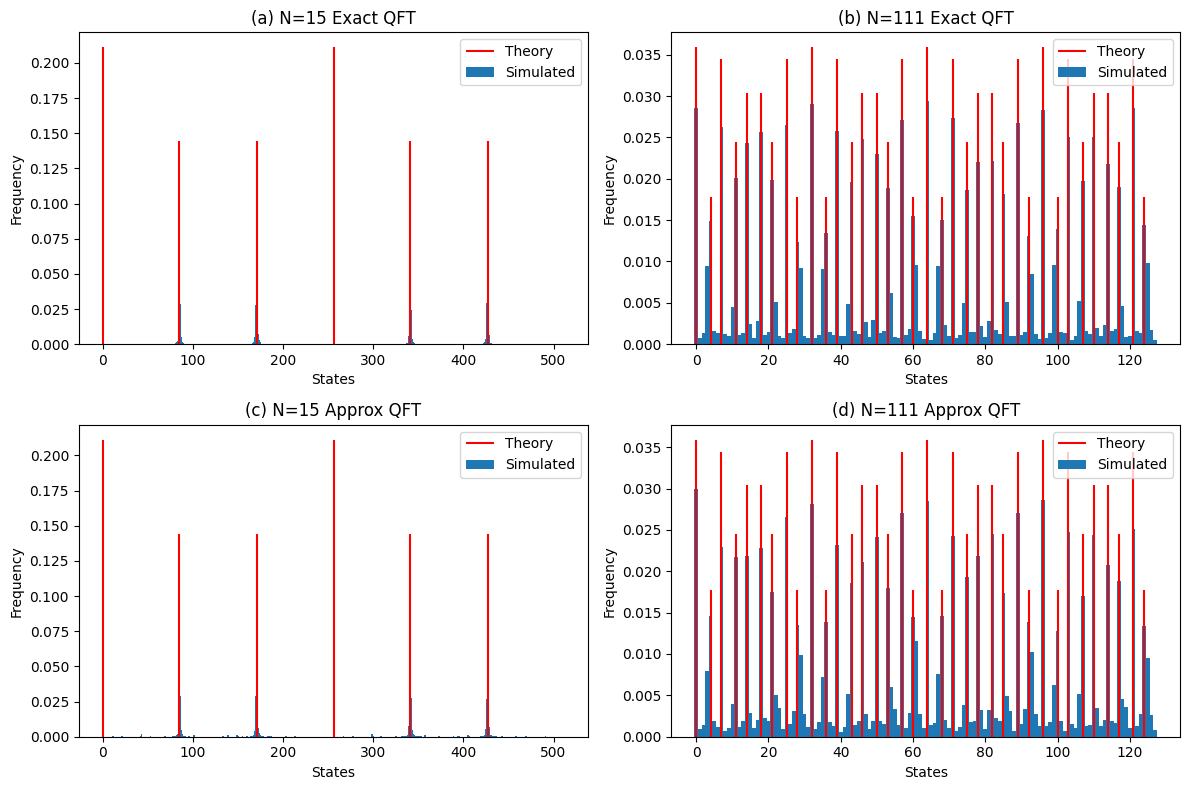

In [15]:
states1 = np.arange(Q1)
states2 = np.arange(Q2)

plt.figure(figsize=(12,8))

# (a) N=15 Exact
plt.subplot(2,2,1)
plt.bar(states1, prob_exact1, label='Simulated', width=2)
peak_x1 = np.where(prob_theory1 > 0)[0]
plt.vlines(peak_x1, 0, prob_theory1[peak_x1], colors='red', linewidth=1.5, label='Theory')
plt.xlabel('States')
plt.ylabel('Frequency')
plt.title("(a) N=15 Exact QFT")
plt.legend()

# (b) N=111 Exact
plt.subplot(2,2,2)
plt.bar(states2, prob_exact2, label='Simulated', width=1)
peak_x2 = np.where(prob_theory2 > 0)[0]
plt.vlines(peak_x2, 0, prob_theory2[peak_x2], colors='red', linewidth=1.5, label='Theory')
plt.xlabel('States')
plt.ylabel('Frequency')
plt.title("(b) N=111 Exact QFT")
plt.legend()

# (c) N=15 Approx
plt.subplot(2,2,3)
plt.bar(states1, prob_approx1, label='Simulated', width=2)
plt.vlines(peak_x1, 0, prob_theory1[peak_x1], colors='red', linewidth=1.5, label='Theory')
plt.xlabel('States')
plt.ylabel('Frequency')
plt.title("(c) N=15 Approx QFT")
plt.legend()

# (d) N=111 Approx
plt.subplot(2,2,4)
plt.bar(states2, prob_approx2, label='Simulated', width=1)
plt.vlines(peak_x2, 0, prob_theory2[peak_x2], colors='red', linewidth=1.5, label='Theory')
plt.xlabel('States')
plt.ylabel('Frequency')
plt.title("(d) N=111 Approx QFT")
plt.legend()

plt.tight_layout()
plt.savefig('fig3_shor.png', dpi=150, bbox_inches='tight')
plt.show()